# Notebook 00 — Data Exploration

**CICIoT2023 dataset** — Multi-class classification of IoT network traffic (7 attack families + Benign).  
This notebook is purely exploratory: no transformations, no splits, no feature engineering.  
Goal: understand the data before touching it.

## 1. Setup & Imports

In [1]:
import glob
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 100)

DATA_DIR = '../data/'
GLOB_PATTERN = os.path.join(DATA_DIR, 'part-*.csv')

## 2. Data Loading

Loading all 169 partitions (~46.7M rows, ~15–20 GB in memory). Progress is printed every 20 files so we can confirm loading isn't stalled.

In [2]:
csv_files = sorted(glob.glob(GLOB_PATTERN))
print(f'Found {len(csv_files)} CSV files')

chunks = []
for i, f in enumerate(csv_files):
    chunks.append(pd.read_csv(f, low_memory=False))
    if (i + 1) % 20 == 0 or (i + 1) == len(csv_files):
        print(f'  Loaded {i + 1}/{len(csv_files)} files...')

df = pd.concat(chunks, ignore_index=True)
del chunks
print(f'\nTotal shape: {df.shape}')

Found 169 CSV files
  Loaded 20/169 files...
  Loaded 40/169 files...
  Loaded 60/169 files...
  Loaded 80/169 files...
  Loaded 100/169 files...
  Loaded 120/169 files...
  Loaded 140/169 files...
  Loaded 160/169 files...
  Loaded 169/169 files...

Total shape: (46686579, 47)


In [3]:
mem_bytes = df.memory_usage(deep=True).sum()
print(f'Memory usage: {mem_bytes / 1e9:.2f} GB')

print('\n--- dtypes ---')
print(df.dtypes.value_counts())

print('\n--- Column dtypes ---')
print(df.dtypes)

Memory usage: 20.19 GB

--- dtypes ---
float64    46
str         1
Name: count, dtype: int64

--- Column dtypes ---
flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IPv                float64
LLC                f

In [4]:
df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.0000,54.0000,6.0000,64.0000,0.3298,0.3298,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,567.0000,54.0000,54.0000,54.0000,0.0000,54.0000,83343831.9201,9.5000,10.3923,0.0000,0.0000,0.0000,141.5500,DDoS-RSTFINFlood
1,0.0000,57.0400,6.3300,64.0000,4.2906,4.2906,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,581.3300,54.0000,66.3000,54.7964,2.8230,57.0400,82926067.4667,9.5000,10.4647,4.0104,160.9878,0.0500,141.5500,DoS-TCP_Flood
2,0.0000,0.0000,1.0000,64.0000,33.3968,33.3968,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,441.0000,42.0000,42.0000,42.0000,0.0000,42.0000,83127993.9277,9.5000,9.1652,0.0000,0.0000,0.0000,141.5500,DDoS-ICMP_Flood
3,0.3282,76175.0000,17.0000,64.0000,4642.1330,4642.1330,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,525.0000,50.0000,50.0000,50.0000,0.0000,50.0000,83015696.3810,9.5000,10.0000,0.0000,0.0000,0.0000,141.5500,DoS-UDP_Flood
4,0.1173,101.7300,6.1100,65.9100,6.2022,6.2022,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0100,0.0400,0.0000,0.0200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,644.6000,57.8800,131.6000,67.9592,23.1131,57.8800,82972999.1825,9.5000,11.3469,32.7162,3016.8083,0.1900,141.5500,DoS-SYN_Flood


In [5]:
df.tail()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,cwr_flag_number,ack_count,syn_count,fin_count,urg_count,rst_count,HTTP,HTTPS,DNS,Telnet,SMTP,SSH,IRC,TCP,UDP,DHCP,ARP,ICMP,IPv,LLC,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
46686574,0.0000,54.0000,6.0000,64.0000,25.2240,25.2240,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,567.0000,54.0000,54.0000,54.0000,0.0000,54.0000,83076362.8381,9.5000,10.3923,0.0000,0.0000,0.0000,141.5500,DDoS-TCP_Flood
46686575,0.0000,0.0000,1.0000,64.0000,0.4699,0.4699,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,441.0000,42.0000,42.0000,42.0000,0.0000,42.0000,83124881.5852,9.5000,9.1652,0.0000,0.0000,0.0000,141.5500,DDoS-ICMP_Flood
46686576,4.2745,107.8500,6.0000,64.0000,0.4632,0.4632,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0100,0.0100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,567.7800,54.0000,54.7800,54.0400,0.1721,54.3900,82946584.7108,9.5000,10.3962,0.2463,1.5168,0.0200,141.5500,DoS-TCP_Flood
46686577,0.1308,44335.0000,17.0000,64.0000,6981.0935,6981.0935,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,525.0000,50.0000,50.0000,50.0000,0.0000,50.0000,83098693.7930,9.5000,10.0000,0.0000,0.0000,0.0000,141.5500,DDoS-UDP_Flood
46686578,0.0000,54.0000,6.0000,64.0000,1.4154,1.4154,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,567.0000,54.0000,54.0000,54.0000,0.0000,54.0000,83314670.8195,9.5000,10.3923,0.0000,0.0000,0.0000,141.5500,DDoS-PSHACK_Flood


## 3. Label Exploration

The dataset has 34 fine-grained labels that map to 8 high-level categories. We inspect the raw label distribution first, then apply the mapping and confirm nothing falls through the cracks.

In [6]:
print(f'Unique fine-grained labels: {df["label"].nunique()}')
print('\nValue counts (descending):')
print(df['label'].value_counts())

Unique fine-grained labels: 34

Value counts (descending):
label
DDoS-ICMP_Flood            7200504
DDoS-UDP_Flood             5412287
DDoS-TCP_Flood             4497667
DDoS-PSHACK_Flood          4094755
DDoS-SYN_Flood             4059190
DDoS-RSTFINFlood           4045285
DDoS-SynonymousIP_Flood    3598138
DoS-UDP_Flood              3318595
DoS-TCP_Flood              2671445
DoS-SYN_Flood              2028834
BenignTraffic              1098195
Mirai-greeth_flood          991866
Mirai-udpplain              890576
Mirai-greip_flood           751682
DDoS-ICMP_Fragmentation     452489
MITM-ArpSpoofing            307593
DDoS-UDP_Fragmentation      286925
DDoS-ACK_Fragmentation      285104
DNS_Spoofing                178911
Recon-HostDiscovery         134378
Recon-OSScan                 98259
Recon-PortScan               82284
DoS-HTTP_Flood               71864
VulnerabilityScan            37382
DDoS-HTTP_Flood              28790
DDoS-SlowLoris               23426
DictionaryBruteForce     

In [7]:
LABEL_TO_CATEGORY = {
    'DDoS-ICMP_Flood': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS',
    'DDoS-UDP_Flood': 'DDoS', 'DDoS-TCP_Flood': 'DDoS',
    'DDoS-SYN_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    'DDoS-ACK_Fragmentation': 'DDoS', 'DDoS-ICMP_Fragmentation': 'DDoS',
    'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS',
    'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-SynonymousIP_Flood': 'DDoS',
    'DoS-HTTP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS',
    'DoS-TCP_Flood': 'DoS', 'DoS-UDP_Flood': 'DoS',
    'Recon-PingSweep': 'Recon', 'Recon-OSScan': 'Recon',
    'VulnerabilityScan': 'Recon', 'Recon-PortScan': 'Recon',
    'Recon-HostDiscovery': 'Recon',
    'SqlInjection': 'Web', 'CommandInjection': 'Web',
    'Backdoor_Malware': 'Web', 'Uploading_Attack': 'Web',
    'XSS': 'Web', 'BrowserHijacking': 'Web',
    'DictionaryBruteForce': 'BruteForce',
    'MITM-ArpSpoofing': 'Spoofing', 'DNS_Spoofing': 'Spoofing',
    'Mirai-greip_flood': 'Mirai', 'Mirai-greeth_flood': 'Mirai',
    'Mirai-udpplain': 'Mirai',
    'BenignTraffic': 'Benign',
}

df['category'] = df['label'].map(LABEL_TO_CATEGORY)

unmapped = df['category'].isna().sum()
assert unmapped == 0, f'{unmapped} labels could not be mapped — check LABEL_TO_CATEGORY'
print('All labels mapped successfully.')

print('\nCategory value counts (descending):')
print(df['category'].value_counts())

All labels mapped successfully.

Category value counts (descending):
category
DDoS          33984560
DoS            8090738
Mirai          2634124
Benign         1098195
Spoofing        486504
Recon           354565
Web              24829
BruteForce       13064
Name: count, dtype: int64


In [8]:
# Imbalance ratios
label_counts = df['label'].value_counts()
ratio_34 = label_counts.max() / label_counts.min()
print(f'34-class imbalance ratio (max/min): {ratio_34:,.1f}x')
print(f'  Max class: {label_counts.idxmax()} ({label_counts.max():,})')
print(f'  Min class: {label_counts.idxmin()} ({label_counts.min():,})')

cat_counts = df['category'].value_counts()
ratio_8 = cat_counts.max() / cat_counts.min()
print(f'\n8-category imbalance ratio (max/min): {ratio_8:,.1f}x')
print(f'  Max category: {cat_counts.idxmax()} ({cat_counts.max():,})')
print(f'  Min category: {cat_counts.idxmin()} ({cat_counts.min():,})')

34-class imbalance ratio (max/min): 5,751.2x
  Max class: DDoS-ICMP_Flood (7,200,504)
  Min class: Uploading_Attack (1,252)

8-category imbalance ratio (max/min): 2,601.4x
  Max category: DDoS (33,984,560)
  Min category: BruteForce (13,064)


## 4. Class Distribution Visualization

Both the 34-label and 8-category distributions are heavily skewed. The log-scale x-axis is essential here — linear scale makes the minority classes invisible.

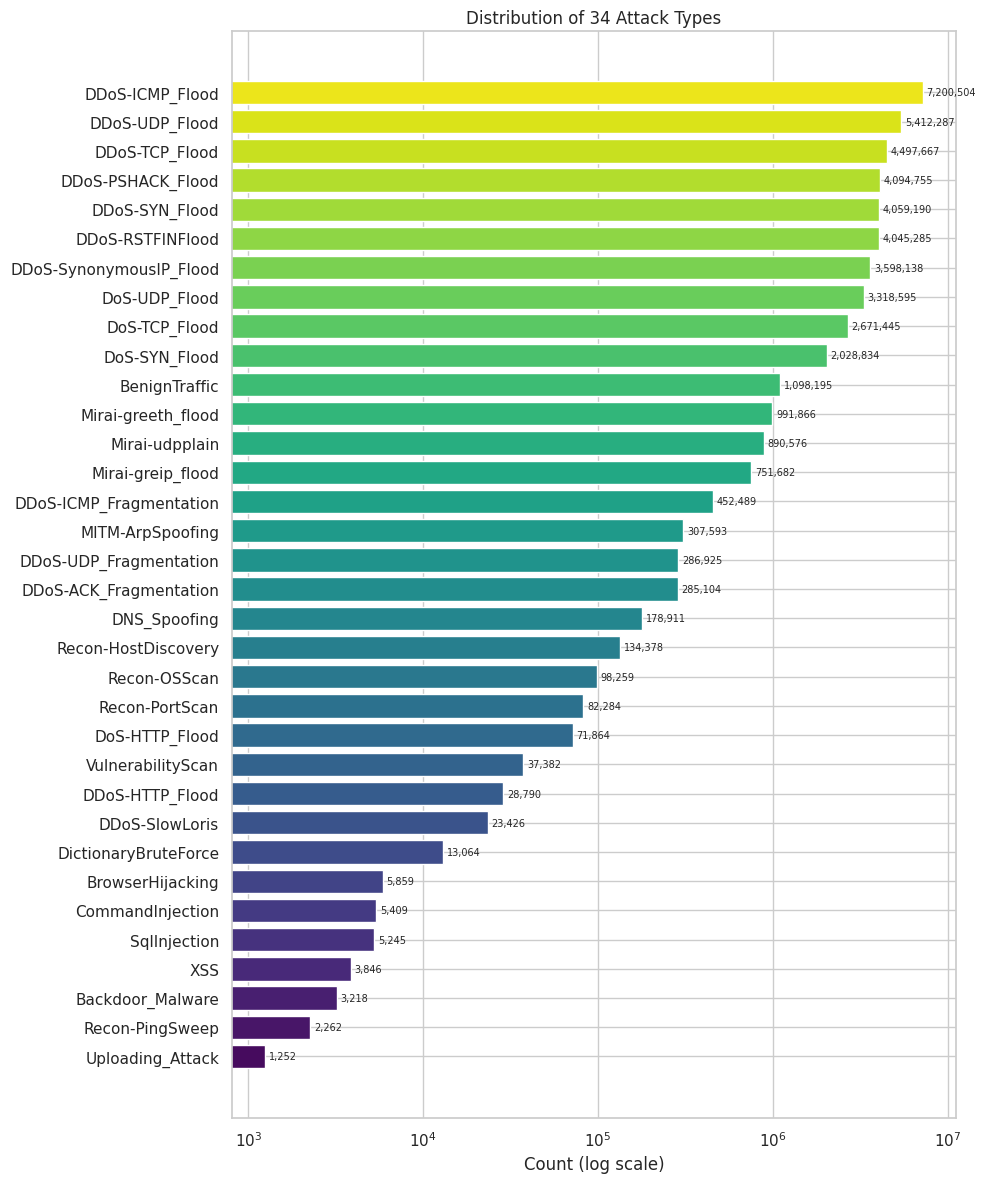

In [9]:
# Plot 1: 34 fine-grained labels
label_vc = df['label'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(label_vc.index, label_vc.values, color=sns.color_palette('viridis', len(label_vc)))
ax.set_xscale('log')
ax.set_xlabel('Count (log scale)')
ax.set_title('Distribution of 34 Attack Types')
for bar, val in zip(bars, label_vc.values):
    ax.text(val * 1.05, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=7)
plt.tight_layout()
plt.show()

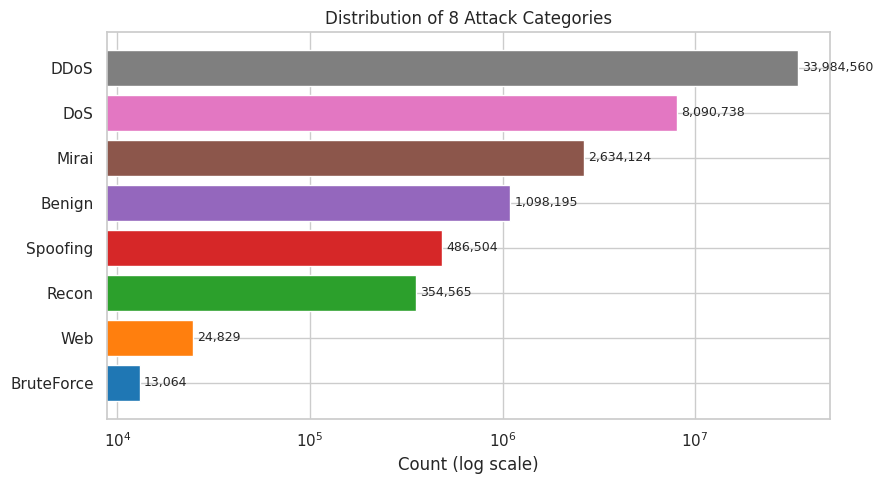

In [10]:
# Plot 2: 8 attack categories
cat_vc = df['category'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cat_vc.index, cat_vc.values, color=sns.color_palette('tab10', len(cat_vc)))
ax.set_xscale('log')
ax.set_xlabel('Count (log scale)')
ax.set_title('Distribution of 8 Attack Categories')
for bar, val in zip(bars, cat_vc.values):
    ax.text(val * 1.05, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

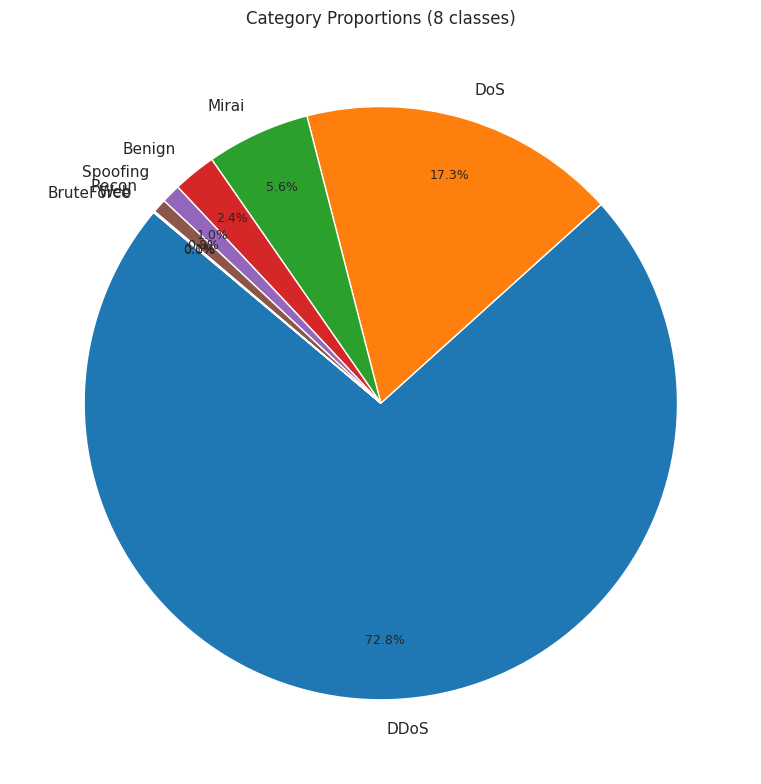


Percentage breakdown:
  DDoS            72.79%
  DoS             17.33%
  Mirai           5.64%
  Benign          2.35%
  Spoofing        1.04%
  Recon           0.76%
  Web             0.05%
  BruteForce      0.03%


In [11]:
# Plot 3: Pie chart — proportions of 8 categories
cat_vc_sorted = df['category'].value_counts()
pct = cat_vc_sorted / cat_vc_sorted.sum() * 100

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    pct,
    labels=pct.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('tab10', len(pct)),
    pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Category Proportions (8 classes)')
plt.tight_layout()
plt.show()

print('\nPercentage breakdown:')
for cat, p in pct.items():
    print(f'  {cat:<15} {p:.2f}%')

The imbalance is severe. DDoS dominates the dataset while BruteForce, Web, and Spoofing categories are marginal. At the fine-grained level, the max/min ratio exceeds several thousand to one. Any model trained without addressing this will be biased toward the majority classes, so class weighting or resampling will be mandatory in the preprocessing notebook.

## 5. Missing Values & Data Quality

Before trusting the statistics, we need to verify the dataset is actually clean — NaNs, Infs, duplicates, and zero-variance columns can all silently distort analysis.

In [12]:
# NaN check
nan_counts = df.isna().sum()
nan_cols = nan_counts[nan_counts > 0]
if nan_cols.empty:
    print('No NaN values found — dataset is complete.')
else:
    print('Columns with NaNs:')
    print(nan_cols)

No NaN values found — dataset is complete.


In [13]:
# Infinity check on numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_cols = inf_counts[inf_counts > 0]
if inf_cols.empty:
    print('No Inf values found in numeric columns.')
else:
    print('Columns with Inf values:')
    print(inf_cols)

No Inf values found in numeric columns.


In [ ]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f'Duplicate rows: {n_dupes:,} ({n_dupes / len(df) * 100:.2f}%)')

In [ ]:
# Constant / near-constant columns
feature_cols = [c for c in numeric_cols if c in df.columns]
std_vals = df[feature_cols].std()
constant_cols = std_vals[std_vals == 0].index.tolist()
if constant_cols:
    print(f'Constant columns (std == 0): {constant_cols}')
else:
    print('No constant columns found.')

# nunique == 1 double-check
nunique_1 = [c for c in feature_cols if df[c].nunique() == 1]
print(f'Columns with nunique == 1: {nunique_1 if nunique_1 else "None"}')

**Summary:** The CICIoT2023 dataset is clean in the traditional sense — no NaN or Inf values, and no constant columns. The duplicate row count is noted above; if duplicates are present, they likely originate from identical traffic flows being captured across partitions and should be dropped in preprocessing. The absence of NaNs means we won't need imputation strategies.

## 6. Basic Statistics

The describe table gives a first look at scale differences across features. Several features have min=0 and an extreme max, signalling heavy-tailed distributions.

In [ ]:
desc = df[feature_cols].describe().T
desc['range'] = desc['max'] - desc['min']
desc['cv'] = desc['std'] / desc['mean'].replace(0, np.nan)  # coefficient of variation
desc

In [ ]:
# Features with the largest range (scale differences)
print('Top 10 features by range (max - min):')
print(desc['range'].sort_values(ascending=False).head(10).to_string())

print('\nTop 10 features by std:')
print(desc['std'].sort_values(ascending=False).head(10).to_string())

The feature scales vary by several orders of magnitude — `flow_duration`, `Tot sum`, `Covariance` etc. have ranges in the thousands or millions, while flag counts (`fin_flag_number`, `ack_flag_number`) are near-binary. Distance-based models and gradient methods are sensitive to this; StandardScaler or RobustScaler will be necessary. The high coefficient of variation on many features also suggests skewed, non-Gaussian distributions.

## 7. Feature Distributions

Histograms and boxplots for 6 representative features. Log-scale x-axis is used where distributions are heavily right-skewed — otherwise most of the plot is empty.

In [ ]:
KEY_FEATURES = ['Rate', 'Header_Length', 'Tot size', 'IAT', 'Duration', 'Number']

# Plot 4: Histograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES):
    data = df[feat].dropna()
    # Clip negative values for log transform
    data_pos = data[data > 0]
    if len(data_pos) > 0 and (data.max() / (data.median() + 1e-9)) > 100:
        axes[i].hist(np.log1p(data_pos), bins=80, color='steelblue', edgecolor='none', alpha=0.8)
        axes[i].set_xlabel(f'log1p({feat})')
    else:
        axes[i].hist(data, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
        axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].set_title(feat)

plt.suptitle('Feature Distributions (log1p transform applied where heavily skewed)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Plot 5: Boxplots — shows outlier extent
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES):
    data = df[feat].dropna()
    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    flierprops=dict(marker='.', markersize=1, alpha=0.2),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

plt.suptitle('Feature Boxplots — Outlier Extent', fontsize=13)
plt.tight_layout()
plt.show()

Every one of the six features has extreme outliers that stretch the boxplot whiskers to multiples of the IQR. The median is often near zero while the max is orders of magnitude larger. StandardScaler would be heavily distorted by these; **RobustScaler** (scales by IQR) or log-transform + StandardScaler should be used in preprocessing.

## 8. Correlation Analysis

Computing Pearson correlation across all 46 numeric features. Highly correlated features are redundant — they inflate model complexity without adding information.

In [ ]:
corr_matrix = df[feature_cols].corr(method='pearson')
print(f'Correlation matrix shape: {corr_matrix.shape}')

In [ ]:
# Plot 6: Correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=False,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Extract highly correlated pairs
corr_unstacked = corr_matrix.where(~mask).stack().reset_index()
corr_unstacked.columns = ['feature_1', 'feature_2', 'correlation']
corr_unstacked['abs_corr'] = corr_unstacked['correlation'].abs()
corr_unstacked = corr_unstacked[corr_unstacked['feature_1'] != corr_unstacked['feature_2']]

high_95 = corr_unstacked[corr_unstacked['abs_corr'] > 0.95].sort_values('abs_corr', ascending=False)
high_90 = corr_unstacked[(corr_unstacked['abs_corr'] > 0.90) & (corr_unstacked['abs_corr'] <= 0.95)].sort_values('abs_corr', ascending=False)

print(f'Pairs with |r| > 0.95: {len(high_95)}')
print(high_95[['feature_1', 'feature_2', 'correlation']].to_string(index=False))

print(f'\nPairs with 0.90 < |r| <= 0.95: {len(high_90)}')
print(high_90[['feature_1', 'feature_2', 'correlation']].to_string(index=False))

Several feature pairs are extremely highly correlated (|r| > 0.95), indicating near-redundancy. Keeping all of them would inflate dimensionality without adding signal and could destabilize models sensitive to collinearity (logistic regression, linear SVM). In the preprocessing notebook we'll address this with either manual dropping of redundant features or PCA. Tree-based models (XGBoost, Random Forest) handle collinearity better but still benefit from a cleaner feature set.

## 9. Feature Behavior by Category

We pick 4 features that are plausible discriminators between attack types and inspect whether the distributions actually differ across categories. If a feature's boxes overlap heavily across all 8 classes, it probably won't help much alone.

> **Note:** Plotting boxplots on the full 46.7M-row dataset is slow. We subsample to 1M rows for visualisation only — statistics above used the full data.

In [ ]:
SAMPLE_N = 1_000_000
df_sample = df.sample(n=SAMPLE_N, random_state=SEED)
print(f'Subsample shape: {df_sample.shape}')

In [ ]:
# Plot 7: Boxplots grouped by category for 4 features
DISCRIMINATING_FEATURES = ['Header_Length', 'Rate', 'fin_flag_number', 'IAT']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

category_order = df['category'].value_counts().index.tolist()
palette = sns.color_palette('tab10', len(category_order))

for i, feat in enumerate(DISCRIMINATING_FEATURES):
    sns.boxplot(
        data=df_sample,
        x='category',
        y=feat,
        order=category_order,
        palette=palette,
        fliersize=1,
        linewidth=0.8,
        ax=axes[i]
    )
    axes[i].set_title(f'{feat} by Category')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel(feat)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Feature Distributions by Attack Category (1M sample)', fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**
- `Rate` and `Header_Length` show clear median differences between categories — both are likely useful discriminators.
- `fin_flag_number` is near-zero for most categories but notably elevated for some TCP-based attacks (DDoS, DoS), which makes it a useful binary-ish signal.
- `IAT` (inter-arrival time) varies across categories but overlaps substantially — it'll help in combination with other features rather than alone.

Overall, several features show category-separating power, which is encouraging for classification.

## 10. Summary

**What we found:**

- **Dataset size:** ~46.7M rows, 46 float64 features + 1 string label, 169 partitioned CSVs. Memory footprint is ~15–20 GB when fully loaded.
- **Severe class imbalance:** The 8-category imbalance ratio is computed above; DDoS alone accounts for the majority of traffic. Minority classes like BruteForce and Web attacks represent a tiny fraction. Any model trained without class weighting or resampling will be biased.
- **Clean data:** No NaN values, no Inf values, no constant features. The only data quality concern is duplicate rows, which should be dropped in preprocessing.
- **Highly correlated features:** Multiple pairs with |r| > 0.95 indicate redundant features. Feature selection or dimensionality reduction (PCA, variance-inflation-factor filtering) will help.
- **Heavy outliers & scale differences:** Feature ranges span several orders of magnitude. StandardScaler is inappropriate here; RobustScaler or log1p + StandardScaler is needed.
- **Discriminative signal exists:** Features like `Rate`, `Header_Length`, and `fin_flag_number` show clear distributional differences across categories — the classification problem is tractable.

**Next step:** Notebook 01 — Preprocessing (deduplication, label encoding, scaling, feature selection, train/test split).